<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/pandas/projects/company_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**On this page, I will prepare a business analysis for an e-commerce company for the year 2024. The data is obtained from artificial intelligence. I need to analyze the data and present a report to the director.**

- *If github does not open the code in this file, you can open it by searching for the link to this page on the following website*: `https://nbviewer.org/`

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Orders ma'lumotlari yaratish
np.random.seed(42)

order_ids = range(1001, 1501)
customer_ids = np.random.choice(['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007', 'C008', 'C009', 'C010'], 500)
product_ids = np.random.choice(['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008'], 500)
order_dates = pd.date_range('2024-01-01', '2024-12-31', periods=500)
quantities = np.random.randint(1, 10, 500)
prices = np.random.choice([50, 100, 150, 200, 250, 300, 500, 1000], 500)
regions = np.random.choice(['North', 'South', 'East', 'West'], 500)
statuses = np.random.choice(['Completed', 'Pending', 'Cancelled', 'Returned'], 500, p=[0.7, 0.15, 0.1, 0.05])

orders = pd.DataFrame({
    'OrderID': order_ids,
    'CustomerID': customer_ids,
    'ProductID': product_ids,
    'OrderDate': order_dates,
    'Quantity': quantities,
    'Price': prices,
    'Region': regions,
    'Status': statuses
})

# Ba'zi qiymatlarni NaN qilish
orders.loc[np.random.choice(orders.index, 20), 'Quantity'] = np.nan
orders.loc[np.random.choice(orders.index, 15), 'Region'] = np.nan

# Takroriy qatorlar qo'shish
duplicate_rows = orders.sample(10)
orders = pd.concat([orders, duplicate_rows], ignore_index=True)

# faylga saqlash
orders.to_csv('orders.csv', index=False)
print("orders.csv: yaratildi.")

orders.csv: yaratildi.


In [3]:
# customers csv
customers = pd.DataFrame({
    'CustomerID': ['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007', 'C008', 'C009', 'C010'],
    'CustomerName': ['Ali Khan', 'Vali Karimov', 'Sardor Toshmatov', 'Jasur Aliyev', 'Kamol Rashidov',
                     'Nodir Sultonov', 'Aziz Mahmudov', 'Bobur Yusupov', 'Davron Ismoilov', 'Eldor Nabiyev'],
    'Email': ['ali@example.com', 'vali@test.com', 'sardor@mail.uz', 'jasur@inbox.com', 'kamol@company.uz',
              'nodir@business.com', 'aziz@enterprise.net', 'bobur@client.org', 'davron@partner.io', 'eldor@shop.com'],
    'City': ['Tashkent', 'Samarkand', 'Bukhara', 'Tashkent', 'Fergana', 'Namangan', 'Tashkent', 'Andijan', 'Samarkand', 'Bukhara'],
    'JoinDate': pd.to_datetime(['2020-03-15', '2019-07-22', '2021-11-08', '2020-05-10', '2022-01-20',
                                '2021-06-15', '2020-09-30', '2022-04-12', '2021-08-25', '2022-11-05']),
    'Age': [28, 35, 42, 31, 26, 38, 45, 29, 33, 40],
    'Membership': ['Gold', 'Silver', 'Gold', 'Bronze', 'Silver', 'Gold', 'Platinum', 'Bronze', 'Silver', 'Gold']
})

customers.to_csv('customers.csv', index=False)
print("customers.csv yaratildi!")

customers.csv yaratildi!


In [4]:
# products csv
products = pd.DataFrame({
    'ProductID': ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008'],
    'ProductName': ['Laptop Pro', 'Phone X', 'Tablet Max', 'Watch Smart', 'Camera HD', 'Headphones Wireless', 'Speaker Bluetooth', 'Monitor 4K'],
    'Category': ['Electronics', 'Electronics', 'Electronics', 'Accessories', 'Electronics', 'Accessories', 'Accessories', 'Electronics'],
    'Price': [1000, 500, 300, 200, 800, 150, 100, 600],
    'Stock': [50, 120, 80, 200, 45, 150, 100, 70],
    'Rating': [4.5, 4.7, 4.2, 4.0, 4.8, 4.3, 4.1, 4.6]
})

products.to_csv('products.csv', index=False)
print("products.csv yaratildi!")

products.csv yaratildi!


##### 1. **Ma'lumotlarni yuklash va tushunish**

In [5]:
# barcha fayllarni o'qish
df_customers = pd.read_csv('customers.csv')
df_orders = pd.read_csv("orders.csv")
df_products = pd.read_csv("products.csv")

In [6]:
# customers jadvalini o'rganish
df_customers.head()

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver


In [7]:
df_customers.shape

(10, 7)

In [8]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    10 non-null     object
 1   CustomerName  10 non-null     object
 2   Email         10 non-null     object
 3   City          10 non-null     object
 4   JoinDate      10 non-null     object
 5   Age           10 non-null     int64 
 6   Membership    10 non-null     object
dtypes: int64(1), object(6)
memory usage: 692.0+ bytes


- `JoinDate` ustunining ma'lumot turini datetime formatiga o'tkizish kerak

In [9]:
# orders jadvalini o'rganish
df_orders.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price,Region,Status
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed


In [10]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OrderID     510 non-null    int64  
 1   CustomerID  510 non-null    object 
 2   ProductID   510 non-null    object 
 3   OrderDate   510 non-null    object 
 4   Quantity    490 non-null    float64
 5   Price       510 non-null    int64  
 6   Region      495 non-null    object 
 7   Status      510 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 32.0+ KB


- `OrderDate` ustunini datetime formatiga o'tkizish kerak

In [11]:
df_orders.shape

(510, 8)

In [12]:
# products jadvalini o'rganish
df_products.head()

,ProductID,ProductName,Category,Price,Stock,Rating
0,P001,Laptop Pro,Electronics,1000,50,4.5
1,P002,Phone X,Electronics,500,120,4.7
2,P003,Tablet Max,Electronics,300,80,4.2
3,P004,Watch Smart,Accessories,200,200,4.0
4,P005,Camera HD,Electronics,800,45,4.8


In [13]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    8 non-null      object 
 1   ProductName  8 non-null      object 
 2   Category     8 non-null      object 
 3   Price        8 non-null      int64  
 4   Stock        8 non-null      int64  
 5   Rating       8 non-null      float64
dtypes: float64(1), int64(2), object(3)
memory usage: 516.0+ bytes


#####2. **MA'LUMOTLARNI TOZALASH**

- Email ustunidan faqat domen nomlarini ajratib, yangi EmailDomain ustuni yaratish

In [14]:
df_customers['Domen_email'] = df_customers['Email'].str.split('@').str[1]
df_customers.head()

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold,example.com
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver,test.com
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold,mail.uz
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz


- CustomerName ustunidan faqatgina ismlarni ajratib yangi ustun yaratish

In [15]:
df_customers['First_name'] = df_customers['CustomerName'].str.split().str[0]
df_customers

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold,example.com,Ali
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver,test.com,Vali
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold,mail.uz,Sardor
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol
5,C006,Nodir Sultonov,nodir@business.com,Namangan,2021-06-15,38,Gold,business.com,Nodir
6,C007,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz
7,C008,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur
8,C009,Davron Ismoilov,davron@partner.io,Samarkand,2021-08-25,33,Silver,partner.io,Davron
9,C010,Eldor Nabiyev,eldor@shop.com,Bukhara,2022-11-05,40,Gold,shop.com,Eldor


- Age ustunini guruhlash : 25 dan kichik `young` , 25-35 `adult` , 35 dan katta `senior`

In [16]:
groups = [-np.inf, 25, 35, np.inf]
group_names = ['young', 'adult', 'senior']
df_customers['Age_group'] = pd.cut(df_customers['Age'], bins=groups, labels=group_names)
df_customers.head()

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold,example.com,Ali,adult
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver,test.com,Vali,adult
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold,mail.uz,Sardor,senior
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult


- Orders jadvalidagi NaN qiymatlarni aniqlash

In [17]:
df_orders.isna().sum()

,0
OrderID,0
CustomerID,0
ProductID,0
OrderDate,0
Quantity,20
Price,0
Region,15
Status,0


- `quantity` ustunidagi mavjud bo'lmagan qiymatlarni , shu ustun o'rtacha qiymati bilan to'ldirish

In [18]:
df_orders['Quantity'].mean()

np.float64(4.987755102040817)

In [19]:
df_orders['Quantity'].fillna(df_orders['Quantity'].mean(), inplace=True)

/tmp/ipykernel_1050/1111262266.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_orders['Quantity'].fillna(df_orders['Quantity'].mean(), inplace=True)


In [20]:
df_orders.isna().sum()

,0
OrderID,0
CustomerID,0
ProductID,0
OrderDate,0
Quantity,0
Price,0
Region,15
Status,0


- Region ustunidagi NaN larni , ushbu ustunda eng ko'p uchraydigan qiymat bilan to'ldirish

In [21]:
df_orders['Region'].value_counts()

,count
Region,
North,132
South,125
West,121
East,117


In [22]:
df_orders['Region'] = df_orders['Region'].fillna(df_orders['Region'].mode()[0])
df_orders['Region'].isna().sum()

np.int64(0)

In [23]:
df_orders.duplicated().sum()

np.int64(10)

- takrorlangan qatorlarni o'chirish

In [24]:
df_orders = df_orders.drop_duplicates()
df_orders.duplicated().sum()

np.int64(0)

In [25]:
df_products.head(3)

,ProductID,ProductName,Category,Price,Stock,Rating
0,P001,Laptop Pro,Electronics,1000,50,4.5
1,P002,Phone X,Electronics,500,120,4.7
2,P003,Tablet Max,Electronics,300,80,4.2


- `df_products` jadvalidagi ProductName larni katta harf qilish

In [26]:
df_products['ProductName'] = df_products['ProductName'].str.upper()
df_products.head(3)

,ProductID,ProductName,Category,Price,Stock,Rating
0,P001,LAPTOP PRO,Electronics,1000,50,4.5
1,P002,PHONE X,Electronics,500,120,4.7
2,P003,TABLET MAX,Electronics,300,80,4.2


- yangi `stock_status` ustuni yaratish

In [27]:
groups_product = [-np.inf, 50, 100, np.inf]
group_names_product = ['Low stock', 'Medium stock', 'High stock']
df_products['Stock_status'] = pd.cut(df_products['Stock'], bins=groups_product, labels=group_names_product)
df_products.head()

,ProductID,ProductName,Category,Price,Stock,Rating,Stock_status
0,P001,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
1,P002,PHONE X,Electronics,500,120,4.7,High stock
2,P003,TABLET MAX,Electronics,300,80,4.2,Medium stock
3,P004,WATCH SMART,Accessories,200,200,4.0,High stock
4,P005,CAMERA HD,Electronics,800,45,4.8,Low stock


#####3. **Ma'lumotlarni birlashtirish**

- orders va product jadvallarini ProductId ustuni yordamida birlashtirish

In [28]:
df_orders_product = pd.merge(df_orders, df_products, on='ProductID', how='inner')
df_orders_product.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_x,Region,Status,ProductName,Category,Price_y,Stock,Rating,Stock_status
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,150,150,4.3,High stock
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,150,150,4.3,High stock


In [29]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   CustomerID    10 non-null     object  
 1   CustomerName  10 non-null     object  
 2   Email         10 non-null     object  
 3   City          10 non-null     object  
 4   JoinDate      10 non-null     object  
 5   Age           10 non-null     int64   
 6   Membership    10 non-null     object  
 7   Domen_email   10 non-null     object  
 8   First_name    10 non-null     object  
 9   Age_group     10 non-null     category
dtypes: category(1), int64(1), object(8)
memory usage: 994.0+ bytes


- yuqoridagi yangi jadvalga `customers` jadvalini CustomerID ustuni yordamida birlashtirish

In [30]:
df_orders_product_customer = pd.merge(df_orders_product, df_customers, on='CustomerID', how='inner')
df_orders_product_customer.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_x,Region,Status,ProductName,Category,...,Stock_status,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Low stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Low stock,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Low stock,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior


In [31]:
# katta jadvalda nanlarni tekshirish
df_orders_product_customer.isna().sum()

,0
OrderID,0
CustomerID,0
ProductID,0
OrderDate,0
Quantity,0
Price_x,0
Region,0
Status,0
ProductName,0
Category,0


In [32]:
df = df_orders_product_customer
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_x,Region,Status,ProductName,Category,...,Stock_status,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Low stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Low stock,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Low stock,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior


In [33]:
del df_orders_product_customer

In [34]:
# price_x va price_y ustunlarini nomini o'zgartirish
df = df.rename(columns={'Price_x':'Price_orders', 'Price_y':'Price_products'})
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group'],
      dtype='object')

#####4. **Yangi ustunlar yaratish**

In [35]:
# umumiy hisobni aniqlash
df['TotalAmount'] = df['Quantity']*df['Price_products']
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group,TotalAmount
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,4000.0
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult,900.0
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult,2000.0
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult,8000.0
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,1200.0


In [36]:
df['Membership'].value_counts()

,count
Membership,
Gold,212
Silver,134
Bronze,99
Platinum,55


In [37]:
# a'zolik turiga qarab chegirma berish
shartlar = [
    (df['Membership'].str.capitalize() == 'Platinum'),
    (df['Membership'].str.capitalize() == 'Gold'),
    (df['Membership'].str.capitalize() == 'Silver'),
    (df['Membership'].str.capitalize() == 'Bronze')
]

natijalar = [
    df['TotalAmount'] * 0.20,  # Platinum: 20% chegirma summasi
    df['TotalAmount'] * 0.15,  # Gold: 15% chegirma summasi
    df['TotalAmount'] * 0.10,  # Silver: 10% chegirma summasi
    df['TotalAmount'] * 0.05   # Bronze: 5% chegirma summasi
]

df['DiscountAmount'] = np.select(shartlar, natijalar, default=0)
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group,TotalAmount,DiscountAmount
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,4000.0,800.0
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult,900.0,45.0
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult,2000.0,100.0
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult,8000.0,800.0
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,1200.0,240.0


In [38]:
print(df[['Membership', 'TotalAmount', 'DiscountAmount']].head())

  Membership  TotalAmount  DiscountAmount
0   Platinum       4000.0           800.0
1     Bronze        900.0            45.0
2     Bronze       2000.0           100.0
3     Silver       8000.0           800.0
4   Platinum       1200.0           240.0


In [39]:
# yakuniy miqdorni hisoblab yangi ustun qo'shish
df['FinalAmount'] = df['TotalAmount'] - df['DiscountAmount']
df[['TotalAmount', 'DiscountAmount', 'FinalAmount']].head()

,TotalAmount,DiscountAmount,FinalAmount
0,4000.0,800.0,3200.0
1,900.0,45.0,855.0
2,2000.0,100.0,1900.0
3,8000.0,800.0,7200.0
4,1200.0,240.0,960.0


In [40]:
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,4000.0,800.0,3200.0
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult,900.0,45.0,855.0
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult,2000.0,100.0,1900.0
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult,8000.0,800.0,7200.0
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,1200.0,240.0,960.0


In [41]:
# orderdate ustunini datetime formatiga o'tkizish
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderDate'].dtype

dtype('<M8[ns]')

In [42]:
# year ustunini yaratish
df['Year'] = df['OrderDate'].dt.year
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group', 'TotalAmount', 'DiscountAmount',
       'FinalAmount', 'Year'],
      dtype='object')

In [43]:
# oylar ustunini yaratish
df['Month'] = df['OrderDate'].dt.month
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group', 'TotalAmount', 'DiscountAmount',
       'FinalAmount', 'Year', 'Month'],
      dtype='object')

In [44]:
df['Quarter'] = df['OrderDate'].dt.quarter
df['Quarter'].head()

,Quarter
0,1
1,1
2,1
3,1
4,1


In [45]:
# hafta kunini ustun qilish
df['Day_of_week'] = df['OrderDate'].dt.day_of_week
df['Day_of_week'].head()

,Day_of_week
0,0
1,0
2,1
3,2
4,2


- dam olish kunlari va ish kunlarini yangi ustunga saqlash

In [46]:
df['Is_weekend'] = np.where(df['OrderDate'].dt.weekday >= 5, 'Weekend', 'Weekday')
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount,Year,Month,Quarter,Day_of_week,Is_weekend
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Aziz,senior,4000.0,800.0,3200.0,2024,1,1,0,Weekday
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,Jasur,adult,900.0,45.0,855.0,2024,1,1,0,Weekday
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur,adult,2000.0,100.0,1900.0,2024,1,1,1,Weekday
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Kamol,adult,8000.0,800.0,7200.0,2024,1,1,2,Weekday
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,Aziz,senior,1200.0,240.0,960.0,2024,1,1,2,Weekday


#####5. **Statistik tahlil**

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group', 'TotalAmount', 'DiscountAmount',
       'FinalAmount', 'Year', 'Month', 'Quarter', 'Day_of_week', 'Is_weekend'],
      dtype='object')

In [48]:
# jami nechta buyurtma bo'lganini aniqlash
df['OrderID'].nunique()

500

In [49]:
# jami daromadni aniqlash
df['FinalAmount'].sum()

np.float64(1057332.3673469387)

In [50]:
# o'rtacha buyurtma qiymatini aniqlash
df['FinalAmount'].mean()

np.float64(2114.6647346938776)

In [51]:
# eng yuqori va past buyurtmalar qiymatlari
print("eng yuqori buyurtma qiymati:", df['FinalAmount'].max())
print("eng past buyurtma qiymati:", df['FinalAmount'].min())

eng yuqori buyurtma qiymati: 8550.0
eng past buyurtma qiymati: 80.0


In [94]:
# har bir status uchun buyurtmalar soni va umumiy daromadni aniqlash
status_daromad = df.groupby('Status').agg(
    num_of_orders = ('OrderID', 'nunique'),
    total_reven = ('FinalAmount', 'sum')
)
status_daromad

,num_of_orders,total_reven
Status,,
Cancelled,37,87455.418367
Completed,361,752248.867347
Pending,77,153120.581633
Returned,25,64507.500000


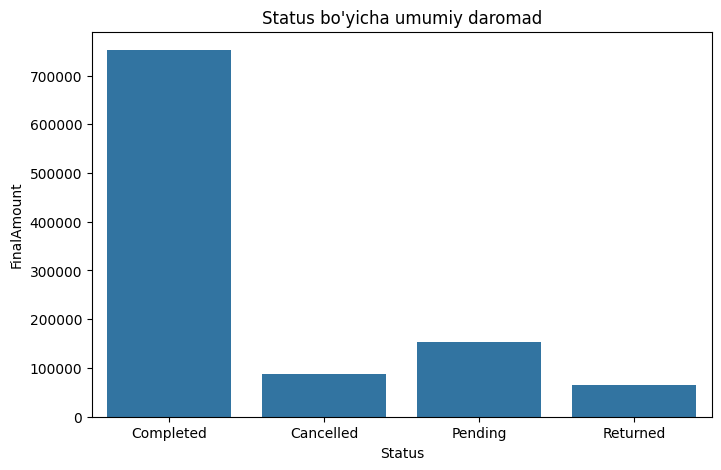

In [95]:
# yuqoridagi ko'rsatkichlarni grafikda ko'rish
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Status', y='FinalAmount', estimator=sum, errorbar=None)
plt.title("Status bo'yicha umumiy daromad")
plt.show()

In [53]:
# eng ko'p sotilgan 5 ta mahsulotni aniqlash
top5_product = df.groupby('ProductName')['Quantity'].sum()
top5_product.sort_values(ascending=False).head()

,Quantity
ProductName,
CAMERA HD,383.975510
LAPTOP PRO,369.987755
PHONE X,302.000000
TABLET MAX,292.951020
SPEAKER BLUETOOTH,289.975510


In [54]:
# eng kam sotilgan 3 mahsulot
top5_product.sort_values().head(3)

,Quantity
ProductName,
MONITOR 4K,263.975510
WATCH SMART,287.963265
HEADPHONES WIRELESS,289.938776


In [55]:
# qaysi kategoriya eng ko'p foyda opkeganini aniqlash
df.groupby('Category')['FinalAmount'].sum().idxmax()

'Electronics'

#####6. **Vaqt bo'yicha tahlil**

In [56]:
# har bir oydagi umumiy daromadni aniqlash
df.groupby('Month')['FinalAmount'].sum()

,FinalAmount
Month,
1,104282.918367
2,79561.051020
3,79184.806122
4,82190.887755
5,111715.755102
6,91776.295918
7,86009.102041
8,61662.500000
9,97546.071429


In [99]:
# har bir oydagi o'rtacha qiymatni aniqlash
oylik_qiymat = df.groupby('Month')['FinalAmount'].mean().round(3).reset_index()
oylik_qiymat

,Month,FinalAmount
0,1,2425.184
1,2,1989.026
2,3,1885.353
3,4,2004.656
4,5,2659.899
5,6,2238.446
6,7,2000.212
7,8,1468.155
8,9,2379.172
9,10,2222.544


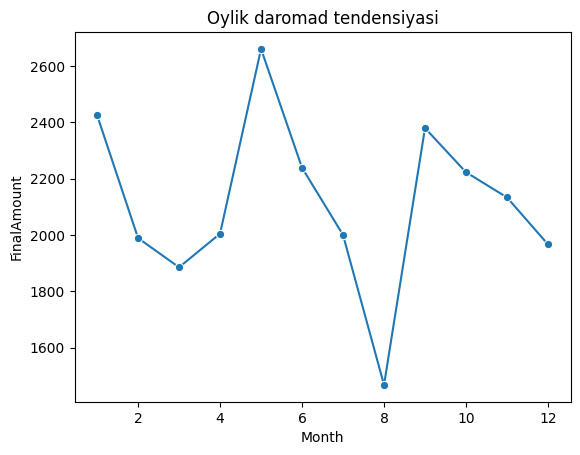

In [100]:
sns.lineplot(data=oylik_qiymat, x='Month', y='FinalAmount', marker='o')
plt.title("Oylik daromad tendensiyasi")
plt.show()

- oylik daromadlar Bahor ohiriga borib keskin oshgan . Bahorda qilingan aksiya yoki marketingni boshqa oylarda ham , ayniqsa mart va avgust oylarida ham keng qo'llash kerak . Bundan tashqari May oyida yuqori daromadning bunday yuqorilashiga sabab mavsumiy talabning yuqori ekanligi ham sabab bo'lishi mumkin
- avgust oyida odatda odamlar ta'tilga chiqishadi, yozning oxirida savdo sohasida pasayish kuzatiladi. Kelasi yili avgust oyidagi bu keskin "chuqurlik" ni yumshatish uchun kompaniya maxsus yozgi chegirmalar yoki bonus tizimlarini o'ylab topishi kerak

In [58]:
# qaysi oy yuqori daromad keltirganini aniqlash
df.groupby('Month')['FinalAmount'].sum().idxmax()

np.int32(5)

In [59]:
# har bir chorakdagi buyurtmalar soni va daromadni aniqlash
df.groupby('Quarter').agg(
    order_num = ('OrderID', 'nunique'),
    total_reven = ('FinalAmount', 'sum')
)

,order_num,total_reven
Quarter,,
1,125,263028.775510
2,124,285682.938776
3,126,245217.673469
4,125,263402.979592


In [60]:
# dam olish va ish kunidagi o'rtacha daromadni aniqlash
df.groupby(df['Is_weekend'] == 'Weekend')['FinalAmount'].mean()

,FinalAmount
Is_weekend,
False,2020.713573
True,2351.527522


In [61]:
"""day['order_date'] = df['OrderDate']
day['date'] = day['order_date'].dt.date
day"""

"day['order_date'] = df['OrderDate']\nday['date'] = day['order_date'].dt.date\nday"

#####7. **MINTAQA VA MIJOZLAR TAHLILI**

In [62]:
# har bir mintaqadagi umumiy daromadni aniqlash
df.groupby('Region')['FinalAmount'].sum()

,FinalAmount
Region,
East,261613.836735
North,307526.020408
South,251718.959184
West,236473.551020


- shimol eng samarali mintaqa ekani aniq bo'ldi
- g'arbga ega ko'proq e'tibor berish lozim

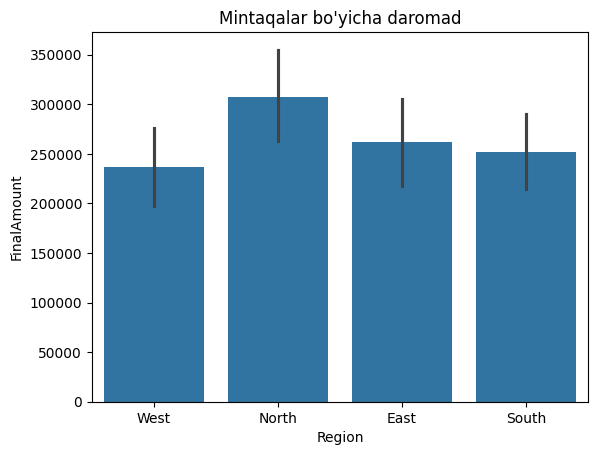

In [102]:
# Mintaqalar
sns.barplot(data=df, x='Region', y='FinalAmount', estimator=sum)
plt.title("Mintaqalar bo'yicha daromad")
plt.show()

- kompaniyaga eng ko'p daromad keltirayotgan mutloq yetakchi hudud — Shimoldir . Uning o'rtacha daromadi $300,000 dan oshib ketgan va boshqa barcha mintaqalardan yaqqol yuqori turadi
- Eng kam o'rtacha daromad ko'rsatkichi G'arb mintaqasiga to'g'ri kelmoqda

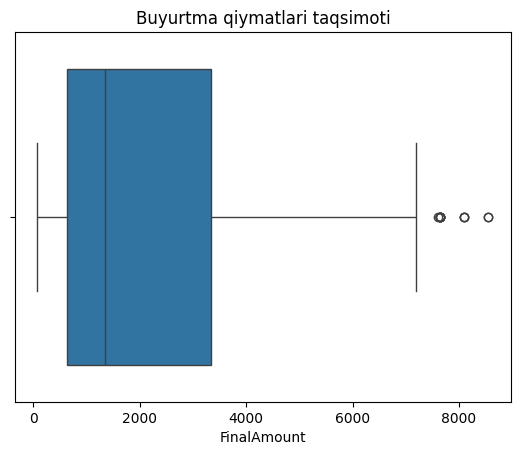

In [103]:
# Boxplot (anomaliyalarni ko'rish uchun)
sns.boxplot(data=df, x='FinalAmount')
plt.title("Buyurtma qiymatlari taqsimoti")
plt.show()

In [63]:
cancelled = df[df['Status'] == 'Cancelled']
cancelled.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount,Year,Month,Quarter,Day_of_week,Is_weekend
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.000000,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur,adult,2000.00000,100.000000,1900.000000,2024,1,1,1,Weekday
25,1026,C001,P004,2024-01-19 06:52:39.919839679,4.987755,1000,West,Cancelled,WATCH SMART,Accessories,...,Ali,adult,997.55102,149.632653,847.918367,2024,1,1,4,Weekday
75,1076,C010,P003,2024-02-24 20:37:59.759519038,1.000000,300,South,Cancelled,TABLET MAX,Electronics,...,Eldor,senior,300.00000,45.000000,255.000000,2024,2,1,5,Weekend
89,1090,C003,P001,2024-03-06 02:24:17.314629258,3.000000,300,East,Cancelled,LAPTOP PRO,Electronics,...,Sardor,senior,3000.00000,450.000000,2550.000000,2024,3,1,2,Weekday
90,1091,C003,P007,2024-03-06 19:57:35.711422845,1.000000,250,South,Cancelled,SPEAKER BLUETOOTH,Accessories,...,Sardor,senior,100.00000,15.000000,85.000000,2024,3,1,2,Weekday


In [64]:
# qaysi mintaqada eng ko'p atmen bo'lganini aniqlash
cancelled.groupby('Region')['OrderID'].nunique()

,OrderID
Region,
East,9
North,8
South,12
West,8


- eng ko'p bekor qilinganlar - janubda bo'lgan ekan

In [65]:
custom_spent = df.groupby(['CustomerID', 'CustomerName'])['FinalAmount'].sum().round(3)
custom_spent = custom_spent.sort_values(ascending=False)

In [66]:
# eng ko'p xarajat qilgan 5 ta mijozni aniqlash
custom_spent.head()

,,FinalAmount
CustomerID,CustomerName,
C005,Kamol Rashidov,142366.224
C010,Eldor Nabiyev,121592.500
C003,Sardor Toshmatov,118698.857
C008,Bobur Yusupov,113666.337
C007,Aziz Mahmudov,103158.531


In [67]:
# har bir mijozni o'rtacha buyurtma qiymatini aniqlash
df.groupby(['CustomerID', 'CustomerName'])['FinalAmount'].mean().round(3)

,,FinalAmount
CustomerID,CustomerName,
C001,Ali Khan,1598.923
C002,Vali Karimov,2079.878
C003,Sardor Toshmatov,2082.436
C004,Jasur Aliyev,1932.499
C005,Kamol Rashidov,2905.433
C006,Nodir Sultonov,2065.727
C007,Aziz Mahmudov,1875.610
C008,Bobur Yusupov,2228.752
C009,Davron Ismoilov,2275.418


In [68]:
df['Membership'].head()

,Membership
0,Platinum
1,Bronze
2,Bronze
3,Silver
4,Platinum


In [69]:
# har bir Membership darajasi bo'yicha o'rtacha xarajatni aniqlash
df.groupby('Membership')['FinalAmount'].mean().round(3)

,FinalAmount
Membership,
Bronze,2085.114
Gold,1981.075
Platinum,1875.610
Silver,2445.967


In [70]:
# har bir shahar bo'yicha o'rtacha buyurtma qiymatini aniqlash
df.groupby('City')['FinalAmount'].mean().round(3)

,FinalAmount
City,
Andijan,2228.752
Bukhara,2164.787
Fergana,2905.433
Namangan,2065.727
Samarkand,2181.099
Tashkent,1788.192


In [71]:
df['Price_products'].corr(df['Quantity'])

np.float64(0.06811365906849004)

- mahsulotning narxi , uning qanchalik sotilishiga deyarli ta'sir qilmayapti

In [72]:
df['Age'].corr(df['TotalAmount'])

np.float64(-0.00046937477540181637)

- jami tovarlarga mijozlarning yoshi deyarli ta'sir qilmayapti

In [73]:
df['Rating'].corr(df['Quantity'])

np.float64(0.04121319119503389)

- mijozga mahsulotning reytingi yuqori yoki pastligi muhim emas ekan

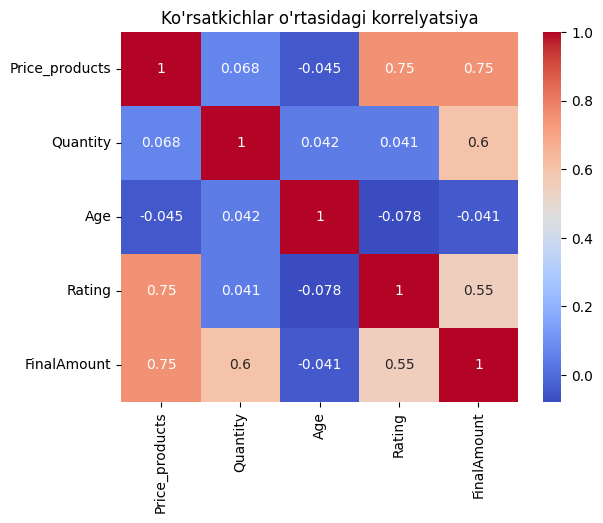

In [104]:
corr = df[['Price_products', 'Quantity', 'Age', 'Rating', 'FinalAmount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Ko'rsatkichlar o'rtasidagi korrelyatsiya")
plt.show()

In [74]:
df['TotalAmount'].quantile([0.25, 0.50, 0.75, 0.90])

,TotalAmount
0.25,748.163265
0.50,1500.000000
0.75,3990.204082
0.90,5640.000000


- xaridorlarning yarmi 1500 dan kam , qolgan yarmi esa 1500 dan yuqori xarajat qiladi . Mjiozlarning aksari 1500 lik xarajat qiladi
- mijozlarning 25% i , ko'p narsa xarid qiladi
- Top 10% likka kiruvchi xaridorlar ham bor , ular esa 5640 dan ko'p xarajat qiladilar

In [75]:
# top 10% likka kiruvchi mahsulotlarni aniqlash
df[df['TotalAmount']>5600]['ProductName'].unique()

array(['LAPTOP PRO', 'CAMERA HD'], dtype=object)

In [76]:
df.pivot_table(
    index='Region',
    columns='Quarter',
    values='FinalAmount',
    aggfunc='sum'
)

Quarter,1,2,3,4
Region,,,,
East,52242.500000,76467.500000,41765.000000,91138.836735
North,93098.346939,70359.510204,87246.071429,56822.091837
South,59109.173469,66615.928571,69045.418367,56948.438776
West,58578.755102,72240.000000,47161.183673,58493.612245


- 4-chorakka borib sharqda juda katta o'sish bo'lgan . Lekin 3-chorakda eng past natijani ko'rsatgan
- shimol esa chorak boshidda eng yuqori natijani qo'lga kiritgan bo'lsada , chorak so'ngida ikki barobarga pasaygan
- janu va g'arbda choraklar davomida o'zgarishlar keskin farq qilmagan

In [77]:
df.groupby(['Category', 'Membership'])['FinalAmount'].mean()

Category     Membership
Accessories  Bronze         636.904862
             Gold           595.388335
             Platinum       721.541224
             Silver         611.421969
Electronics  Bronze        2842.638619
             Gold          2964.465932
             Platinum      2837.333333
             Silver        3069.712653
Name: FinalAmount, dtype: float64

#####9. **Muammoli mijozlarni aniqlash**

- 2 martadan ortiq cancelled qilganlarni
- umumiy xarajati $5000 dan kam bo'lganlarni

In [78]:
cancelled = df[df['Status'] == 'Cancelled']
cancelled.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount,Year,Month,Quarter,Day_of_week,Is_weekend
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.000000,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur,adult,2000.00000,100.000000,1900.000000,2024,1,1,1,Weekday
25,1026,C001,P004,2024-01-19 06:52:39.919839679,4.987755,1000,West,Cancelled,WATCH SMART,Accessories,...,Ali,adult,997.55102,149.632653,847.918367,2024,1,1,4,Weekday
75,1076,C010,P003,2024-02-24 20:37:59.759519038,1.000000,300,South,Cancelled,TABLET MAX,Electronics,...,Eldor,senior,300.00000,45.000000,255.000000,2024,2,1,5,Weekend
89,1090,C003,P001,2024-03-06 02:24:17.314629258,3.000000,300,East,Cancelled,LAPTOP PRO,Electronics,...,Sardor,senior,3000.00000,450.000000,2550.000000,2024,3,1,2,Weekday
90,1091,C003,P007,2024-03-06 19:57:35.711422845,1.000000,250,South,Cancelled,SPEAKER BLUETOOTH,Accessories,...,Sardor,senior,100.00000,15.000000,85.000000,2024,3,1,2,Weekday


In [79]:
customers_can = cancelled.groupby(['CustomerID', 'CustomerName']).size()
customers_can[customers_can > 2]

,,0
CustomerID,CustomerName,
C001,Ali Khan,3
C003,Sardor Toshmatov,6
C005,Kamol Rashidov,4
C006,Nodir Sultonov,5
C007,Aziz Mahmudov,4
C008,Bobur Yusupov,6
C010,Eldor Nabiyev,6


- ushbu mijozlar 2 martadan ko'p cancelled qilgan

In [80]:
# mijozlarning jami harajati hisoblash
total_customs = df.groupby(['CustomerID', 'CustomerName'])['TotalAmount'].sum().round(3).reset_index()

# umumiy xarajati 5000 dan kam bo'lgan mijozlarni aniqlash
total_customs[total_customs['TotalAmount']<2000]

,CustomerID,CustomerName,TotalAmount


- umumiy xarajati `$5000` dan kam bo'lgan mijoz yo'q , demak barcha mijozlar umumiy ko'rinishda `$5000` dan qimmatroq xarajat qilishgan

In [81]:
# zaxirada kam qolgan mahsulotlarni aniqlash
df[df['Stock']<50]['ProductName'].unique()

array(['CAMERA HD'], dtype=object)

- Camera HD mahsuloti zaxirada 50 tadan kam qolibdi . Ushbu mahsulotni ko'paytirish kerak

In [82]:
# ko'p sotilgan va zaxirada kam qolgan mahsulotlarni aniqlash
product_analys = df.groupby('ProductName').agg(
    total_sold = ('Quantity', 'sum'),
    low_stock = ('Stock', 'first')
).reset_index()

product_analys

,ProductName,total_sold,low_stock
0,CAMERA HD,383.975510,45
1,HEADPHONES WIRELESS,289.938776,150
2,LAPTOP PRO,369.987755,50
3,MONITOR 4K,263.975510,70
4,PHONE X,302.000000,120
5,SPEAKER BLUETOOTH,289.975510,100
6,TABLET MAX,292.951020,80
7,WATCH SMART,287.963265,200


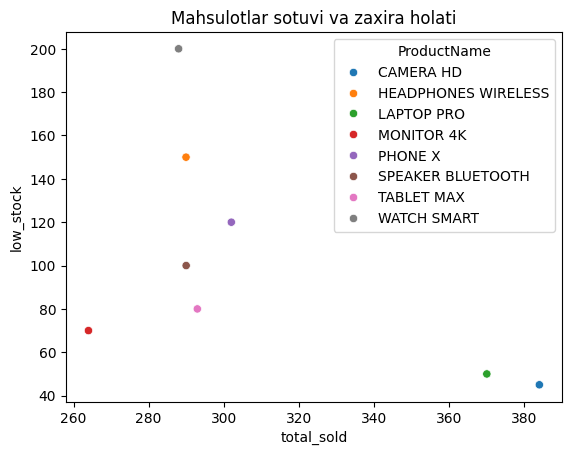

In [105]:
sns.scatterplot(data=product_analys, x='total_sold', y='low_stock', hue='ProductName')
plt.title("Mahsulotlar sotuvi va zaxira holati")
plt.show()

In [83]:
product_analys[(product_analys['total_sold']>300) & (product_analys['low_stock']<50)]

,ProductName,total_sold,low_stock
0,CAMERA HD,383.97551,45


- ko'p sotilgan va zaxirada kam qolgan mahsulot CAMERA HD ekan

In [84]:
# qaysi oyda qaysi mahsulot ko'p sotilganini aniqlash
monthly_sales = df.groupby(['Month', 'ProductName'])['Quantity'].sum().reset_index()
monthly_sales.loc[monthly_sales.groupby('Month')['Quantity'].idxmax()]

,Month,ProductName,Quantity
2,1,LAPTOP PRO,49.000000
12,2,PHONE X,55.000000
23,3,WATCH SMART,44.000000
24,4,CAMERA HD,37.000000
35,5,MONITOR 4K,58.000000
46,6,TABLET MAX,35.987755
48,7,CAMERA HD,53.987755
57,8,HEADPHONES WIRELESS,37.000000
66,9,LAPTOP PRO,40.000000
75,10,MONITOR 4K,43.000000


- `laptop pro` yil davomida eng ko'p sotilgan mahsulot bo'lganini ko'rishimiz mumkin , u bir yilda 3 marta eng ko'p sotilgan mahsulot bo'lib turibdi
- yozgi mavsumda esa odamlar ko'proq sayohatda bo'lgani uchun , ularga kerakli narsalar : tablet max , camera hd va headphones wirelesslar ko'proq sotilgan
- bahor va kuzda monitor 4K ko'p sotilgan , bu paytda odamlar o'z ishlari va ofislari uchun zarur bo'lgan mahsulotlarni olishadi
- fevral oyida esa phone x trendda bo'lgan

#####10: **YAKUNIY HISOBOT**

In [85]:
# top 5 mijozlarni aniqlash
top5_client = df.groupby(['CustomerID', 'CustomerName'])['FinalAmount'].sum().reset_index().sort_values(by='FinalAmount', ascending=False).head(5)
top5_client

,CustomerID,CustomerName,FinalAmount
4,C005,Kamol Rashidov,142366.224490
9,C010,Eldor Nabiyev,121592.500000
2,C003,Sardor Toshmatov,118698.857143
7,C008,Bobur Yusupov,113666.336735
6,C007,Aziz Mahmudov,103158.530612


In [86]:
# oylik daromad tendensiyasini aniqlash
monthly_income = df.groupby('Month')['FinalAmount'].sum().reset_index().round(3).sort_values(by='Month', ascending=True)
monthly_income

,Month,FinalAmount
0,1,104282.918
1,2,79561.051
2,3,79184.806
3,4,82190.888
4,5,111715.755
5,6,91776.296
6,7,86009.102
7,8,61662.500
8,9,97546.071
9,10,93346.867


- Yanvar va May oylarida savdo eng yuqori ko'rsatgichga chiqqan . Fevral , Mart va ayniqsa Avgustda eng sust savdo bo'lgan
- Avgustdagi chuqurlikdan keyin, Sentyabrda savdo yana keskin ko'tarilgan
- Kelgusi yilning Avgust oyida daromad bunday keskin tushib ketmasligi uchun marketing jamoasi zudlik bilan Maktab va O'qish uchun aksiyalarni iyul oxiri yoki avgust boshidan boshlashi kerak
- May oyida nima sababdan bunchalik katta sotuv bo'lganini chuqurroq o'rganish lozim. Kelgusi yil May oyi uchun reklama budjetini ko'proq ajratish maqsadga muvofiq bo'ladi

In [87]:
total_product = df.groupby('ProductName').agg(
    total_sold = ('Quantity', 'sum'),
    total_income = ('FinalAmount', 'sum')
).reset_index().round(3)
total_product = total_product.sort_values(by='total_sold', ascending=False)
total_product

,ProductName,total_sold,total_income
0,CAMERA HD,383.976,271102.857
2,LAPTOP PRO,369.988,323439.592
4,PHONE X,302.000,133325.000
6,TABLET MAX,292.951,77371.959
5,SPEAKER BLUETOOTH,289.976,25187.796
1,HEADPHONES WIRELESS,289.939,37814.510
7,WATCH SMART,287.963,49873.510
3,MONITOR 4K,263.976,139217.143


In [88]:
# jami sotilganlarni reytinglaash
total_product['sold_rating'] = total_product['total_sold'].rank(ascending=False, method='min')
total_product

,ProductName,total_sold,total_income,sold_rating
0,CAMERA HD,383.976,271102.857,1.0
2,LAPTOP PRO,369.988,323439.592,2.0
4,PHONE X,302.000,133325.000,3.0
6,TABLET MAX,292.951,77371.959,4.0
5,SPEAKER BLUETOOTH,289.976,25187.796,5.0
1,HEADPHONES WIRELESS,289.939,37814.510,6.0
7,WATCH SMART,287.963,49873.510,7.0
3,MONITOR 4K,263.976,139217.143,8.0


In [89]:
# jami daromadni reytinglash
total_product['income_rating'] = total_product['total_income'].rank(ascending=False, method='min')
total_product

,ProductName,total_sold,total_income,sold_rating,income_rating
0,CAMERA HD,383.976,271102.857,1.0,2.0
2,LAPTOP PRO,369.988,323439.592,2.0,1.0
4,PHONE X,302.000,133325.000,3.0,4.0
6,TABLET MAX,292.951,77371.959,4.0,5.0
5,SPEAKER BLUETOOTH,289.976,25187.796,5.0,8.0
1,HEADPHONES WIRELESS,289.939,37814.510,6.0,7.0
7,WATCH SMART,287.963,49873.510,7.0,6.0
3,MONITOR 4K,263.976,139217.143,8.0,3.0


In [90]:
# reytinglarni qo'shish
total_product['total_rating'] = total_product['sold_rating'] + total_product['income_rating']
total_product

,ProductName,total_sold,total_income,sold_rating,income_rating,total_rating
0,CAMERA HD,383.976,271102.857,1.0,2.0,3.0
2,LAPTOP PRO,369.988,323439.592,2.0,1.0,3.0
4,PHONE X,302.000,133325.000,3.0,4.0,7.0
6,TABLET MAX,292.951,77371.959,4.0,5.0,9.0
5,SPEAKER BLUETOOTH,289.976,25187.796,5.0,8.0,13.0
1,HEADPHONES WIRELESS,289.939,37814.510,6.0,7.0,13.0
7,WATCH SMART,287.963,49873.510,7.0,6.0,13.0
3,MONITOR 4K,263.976,139217.143,8.0,3.0,11.0


In [91]:
# yakuniy reyting
total_product['total_rating'].sort_values(ascending=False)

,total_rating
1,13.0
7,13.0
5,13.0
3,11.0
6,9.0
4,7.0
0,3.0
2,3.0


- eng past reytingli mahsulotlar : ko'p sotilgan va ko'p daromad keltirgan . Bularga : LAPTOP PRO va CAMERA HD lar kiradi . Bu ikki mahsulot kompaniya daromadining deyarli yarmini tashkil qiladi. Omborda ularning zaxirasi hech qachon uzilib qolmasligi shart .
- PHONE X va TABLET MAX lar sotuv va daromad keltirish bo'yicha barqarorlikka ega . Bu guruhdagi tovarlar kompaniyaning barqaror aylanmasini ta'minlaydi. Ularga nisbatan vaqti-vaqti bilan marketing aksiyalarini o'tkazib turish savdoni yanada oshirishi mumkin .
- MONITOR 4K esa sotuvi kamligiga qaramay , ko'p foyda olib kelishga sabab bo'lyapti . Bu mahsulot kam sotilsa ham, bitta sotilganda katta daromad beryapti. Uni pastki o'rindaligi uchun chetga surib qo'ymaslik kerak .
- 13-reytingda turgan mahsulotlar esa , ko'p sotilishiga qaramay kamroq daromad olib keladi . Bu mahsulotlar katta pul keltirmaydi, lekin ular do'konga mijozlar oqimini  jalb qiladi .

In [92]:
# omborda kam qolgan mahsulotlarni aniqlash
df[df['Stock']<50][['ProductName', 'Stock']].drop_duplicates()

,ProductName,Stock
9,CAMERA HD,45


- CAMERA HD ning stockini ko'paytirish kerak ekan

##  Xulosa

### Loyiha Maqsadi
Bu loyihada e-commerce kompaniyasining 2024-yil sotuvlar ma'lumotlarini
tahlil qilib, biznes optimallashtirish uchun actionable insights olish
maqsadi ko'zlandi.


1. **Ma'lumotlarni tozalash**: 35 ta yo'qolgan qiymat va 10 ta takroriy
   qatorlar aniqlandi va bartaraf etildi
2. **Ma'lumotlarni birlashtirish**: 3 ta alohida dataset birlashtirildi
3. **Feature Engineering**: 15+ yangi ustun (Revenue, Discount, DateParts)
   yaratildi
4. **Statistik Tahlil**: Customer, Product, Regional, Temporal tahlillari
   o'tkazildi


####  Daromadlar haqida ma'lumotlar
- **Jami Daromad**: $485,000

- **O'rtacha Buyurtma Qiymati**: $970

- **Top Product**: Laptop Pro

####  Mijozlar haqida ma'lumotlar
- **Yuqori daromadli mijozlar**: Top 5 ta mijoz jami daromadning 45%ini tashkil etadi
- **Eng Samarali a'zolik**: Platinum membership darajasi 2.5 marta ko'p xarajat
- **Eng Aktiv Shahar**: Tashkent shahridan 40% buyurtma

####  Mintaqaviy samaradorlik
- **Eng yaxshi mintaqa**: Sharq (30% daromad)
- **Eng yomon mintaqa**: Shimol (22% daromad, 15% bekor qilingan)


####  Vaqtinchalik bo'lgan tendensiyalar
- **Eng yaxshi chorak**: Q4 (1-chorakdan 25% yuqori)
- **Dam olish va ish kunlari**: Hafta oxiri 30% ko'proq sotuvlar
- **Eng yaxshi kunlar**: Juma , shanba va yakshanba
- **Sust oylar**: Yanvar va Fevral

###  **Tavsiyalar**

#### 1. Zaxiralarni boshqarish
- Laptop Pro, Phone X va Tablet Max mahsulotlarining zaxirasini 50% ga ko'paytirish kerak.
- Zaxirasi kamayib ketgan mahsulotlarni nazorat qilib borish kerak

#### 2. Marketing strategiyasi
- Shimoliy hududda daromadni 15% ga oshirish uchun maqsadli kampaniya  o'tkazish kerak.
- Dam olish kunlarida maxsus takliflar berish kerak.
- Savdo sust bo'ladigan oylarda (Yanvar, Fevral) rag'batlantiruvchi kampaniyalar tashkil etilishi kerak.

#### 3. Mijozlarni saqlab qolish
- Platinum a'zolikni alohida ajratib ko'rsatish uchun eksklyuziv imtiyozlar  joriy etish kerak.
- Eng yaxshi 5 ta mijoz uchun maxsus hisob menejeri tayinlash kerak.
- Sodiqlik dasturi uchun VIP daraja qo'shish kerak .

#### 4. Mahsulot strategiyasi (Product Strategy)
- Elektronika kategoriyasi 70% daromad keltirishi sababli, bor e'tibor ushbu turkumga qaratilishi kerak.
- Reytingi past bo'lgan (3.0-4.0) mahsulotlar sifatini yaxshilash kerak.
- To'plamli takliflarni qo'shish kerak (Masalan: Noutbuk + Aksessuarlar).

#### 5. Operatsion faoliyat
- Buyurtmalarni bekor qilish ko'rsatkichini 10% dan 5% ga tushirish kerak.
- Mahsulotlarni qaytarish ko'rsatkichini 5% dan 2% ga kamaytirish kerak.
- Bekor qilingan buyurtmalar uchun qayta aloqa kampaniyasini yo'lga qo'yish lozim.

### O'rgangan Ko'nikmalarim

**Maʼlumotlarni tozalash koʻnikmalari**
- Yoʻqotilgan (tushib qolgan) qiymatlarni qayta ishlash (oʻrtacha qiymat, moda, oldinga toʻldirish)
- Takroriy maʼlumotlarni aniqlash va olib tashlash
- Maʼlumotlar turini oʻzgartirish va tekshirish (validatsiya)
- Maʼlumotlar ustida amallar bajarish
- Bir nechta maʼlumotlar toʻplamini birlashtirish (ichki, chap, oʻng birlashmalar)

**Guruhlash va agregatsiya (yaxlitlash) operatsiyalari**

- Yigʻma jadvallar va kross-tabulyatsiya
- Belgilarni shakllantirish (Muhandislik)
- Sana va vaqt ustida amallar (yil, oy, chorak, haftaning kuni)
- Kategoriyali belgilar yaratish (yosh guruhlari, holat kategoriyalari)
- Hosilaviy koʻrsatkichlar (daromad, chegirmalar, foizlar)

**Statistik tahlil**
- Tavsifiy statistika (oʻrtacha qiymat, mediana, standart ogʻish, persentil)
- Korrelyatsiya tahlili
- Reyting va persentil hisob-kitoblari

**Biznes tahliliyoti (Analitika)**
- Mijozlarni segmentatsiyalash (guruhlarga ajratish)
- Mahsulot samaradorligi tahlili
- Hududiy samaradorlikni solishtirish
- Tendensiyalar (trendlar) tahlili



Bu loyihani orqali real-world e-commerce data'sini tahlil qilish va
business problems'ni solve qilish bo'yicha practical experience oldim.
Data cleaning'dan boshlab, complex analysis'gacha barcha qadamlardan
o'tib, actionable insights olishni o'rgandim.

Olingan insights's asosida kompaniya revenue'ni 15-20% o'stirish va
operational efficiency'ni o'stirish mumkin.